# Notebook con el codigo correspondiente para entrenar los distintos modelos
### Unicamente entrena y almacena los modelos. 
### Debido al elevado tiempo de entrenamiento se incluye un cuaderno separado para la evaluación de los modelos, incluyendo modelos preentrenados utilizando la estructura implementada en este cuaderno


In [64]:
# Instalamos las dependencias necesarias
!pip install stable-baselines3[extra] gymnasium numpy matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
# Uso basico
import numpy as np
import matplotlib.pyplot as plt

# Gym
import gymnasium as gym
from gymnasium import spaces

# Stable baselines
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.logger import configure
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback

# Sistema y rutas
from pathlib import Path
import os
import glob

## Rutas de almacenado de los modelos y parametros de entrenamiento
###  Descomentar la celda correspondiente dependiendo de almacenamiento en drive mediante colab o de manera local
### El guardado en drive requiere dar acceso a la cuenta

In [66]:
# # Almacenado en google drive desde colab. 
# from google.colab import drive

# drive.mount('/content/drive')

# DRIVE_PATH = Path("/content/drive/MyDrive/rl_project")

# MODEL_PATH = DRIVE_PATH / "models"
# LOG_PATH = DRIVE_PATH / "logs"

# MODEL_PATH.mkdir(parents=True, exist_ok=True)
# LOG_PATH.mkdir(parents=True, exist_ok=True)

In [67]:
# Almacenado local
BASE_PATH = Path("./RL_entrenamiento")

MODEL_PATH = BASE_PATH / "models"
LOG_PATH = BASE_PATH / "logs"

MODEL_PATH.mkdir(parents=True, exist_ok=True)
LOG_PATH.mkdir(parents=True, exist_ok=True)

## Definimos los potenciales para entrenar al modelo

In [68]:
# Gaussianas
def gaussianas_gradiente(n=3):
    '''
    Funcion que devuelve funciones de potencial con n gaussianas y sus gradientes
    '''
    centers = np.random.uniform(0, 1, size=(n, 2))
    amps = np.random.uniform(0.5, 1.5, size=n)
    sigmas = np.random.uniform(0.05, 0.15, size=n)

    def V(x, y):
        dx = x - centers[:,0]
        dy = y - centers[:,1]
        r2 = dx*dx + dy*dy
        return -np.sum(amps * np.exp(-r2/(2*sigmas**2)))

    def gradV(x, y):
        dx = x - centers[:,0]
        dy = y - centers[:,1]
        r2 = dx*dx + dy*dy

        exp_term = np.exp(-r2/(2*sigmas**2))
        coeff = amps * exp_term / (sigmas**2)

        gx = np.sum(coeff * dx)
        gy = np.sum(coeff * dy)

        grad = np.array([gx, gy], dtype=np.float32)
        return grad / (np.linalg.norm(grad) + 1e-8)

    return V, gradV


# Seno/coseno
def sin_cos_grad():
    '''
    Funcion equivalente con senos y cosenos
    '''
    def V(x, y):
        return np.sin(3*x)*np.cos(3*y)

    def gradV(x, y):
        gx = 3*np.cos(3*x)*np.cos(3*y)
        gy = -3*np.sin(3*x)*np.sin(3*y)
        grad = np.array([gx, gy], dtype=np.float32)
        return grad / (np.linalg.norm(grad) + 1e-8)

    return V, gradV


# sampler
def sample_potential():
    '''
    Funcion que elige un potencial aleatorio para pasar al entorno
    '''
    if np.random.rand() < 0.5:
        return gaussianas_gradiente()
    else:
        return sin_cos_grad()





## Definimos el entorno de gymnasium para los modelos 

In [69]:
class FastGradEnv(gym.Env):
    def __init__(self, max_steps=350, weights=None):
        super().__init__()

        # Parametros del sistema
        self.max_steps = max_steps
        self.dt = 0.02
        self.speed = 0.25

        self.energy = 0.0
        self.path_length = 0.0
        self.start_pos = np.zeros(2)

        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)


        # Lo que devuelve obs [x, y, dx_goal, dy_goal, V, gx, gy]:
        #   [0] x        - posición en x          (en [0, 1])
        #   [1] y        - posición en y          (en [0, 1])
        #   [2] dx_goal  - delta x hacia el goal  (en [-1, 1])
        #   [3] dy_goal  - delta y hacia el goal  (en [-1, 1])
        #   [4] V        - potencial local         (en [-2, 2])
        #   [5] gx       - gradiente en x          (en [-1, 1])
        #   [6] gy       - gradiente en y          (en [-1, 1])
        self.observation_space = spaces.Box(
            low=np.array( [0.0,  0.0,  -1.0, -1.0, -2.0, -1.0, -1.0], dtype=np.float32),
            high=np.array([1.0,  1.0,   1.0,  1.0,  2.0,  1.0,  1.0], dtype=np.float32),
            dtype=np.float32
        )


        self.weights = weights or {
            "progress": 16,
            "align": 0.03,
            "slope": 0.005,
            "potential": 0.02,
            "step": 0.005
        }

    # Funcion de reinicio, elige un nuevo potencial, posiciones y goal aleatorios
    # evita exactamente situarsse en el borde de la caja
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.V_fn, self.grad_fn = sample_potential()

        self.pos  = self.np_random.uniform(0.05, 0.95, 2).astype(np.float32)
        self.goal = self.np_random.uniform(0.05, 0.95, 2).astype(np.float32)

        # Almacenamos la posicion inicial
        self.start_pos = self.pos.copy()

        self.steps = 0


        self.energy      = 0.0
        self.path_length = 0.0

        return self._obs(), {}

    def _obs(self):
        V    = float(np.clip(self.V_fn(self.pos[0], self.pos[1]), -2, 2))
        grad = self.grad_fn(self.pos[0], self.pos[1])

        # Normalizar el vector dirección al goal para que quede en [-1, 1]
        delta     = self.goal - self.pos
        dist      = np.linalg.norm(delta) + 1e-8
        dir_goal  = (delta / dist).astype(np.float32)

        # Normalizar gradiente a [-1, 1] para respetar observation_space
        grad_norm = grad / (np.linalg.norm(grad) + 1e-8)

        return np.concatenate([
            self.pos,       # [0, 1]
            dir_goal,       # [-1, 1]
            [V],            # [-2, 2]
            grad_norm       # [-1, 1]
        ]).astype(np.float32)

    def step(self, action):
        # El agente elige un angulo y se mueve en esa direccion
        # es necesario action[0] porque esta definido como un vector
        theta     = float(action[0] * np.pi)
        direction = np.array([np.cos(theta), np.sin(theta)], dtype=np.float32)

        prev_pos  = self.pos.copy()

        # Actualizamos la posicion
        self.pos  = prev_pos + self.speed * direction * self.dt
        self.steps += 1

        # Distancia a la meta y distancia previa
        dist      = np.linalg.norm(self.goal - self.pos)
        prev_dist = np.linalg.norm(self.goal - prev_pos)

        # Calculamos el progreso
        r_progress = prev_dist - dist

        # Comprobar la direccion y alineamiento. Usamos prev porque ya hemos actualizado posiciones
        goal_dir   = (self.goal - prev_pos) / (prev_dist + 1e-8)
        r_align    = float(np.dot(direction, goal_dir))

        V    = float(np.clip(self.V_fn(self.pos[0], self.pos[1]), -2, 2))
        Vp    = float(np.clip(self.V_fn(prev_pos[0], prev_pos[1]), -2, 2))
        dV = Vp - V
        grad = self.grad_fn(self.pos[0], self.pos[1])

        # Añadimos la energia y longitud del paso
        self.energy      += V
        self.path_length += self.speed * self.dt


        # Funcion de reward ajustada con los pesos proporcionados o por defecto
        w = self.weights
        reward = (
              w["progress"]  * r_progress
            + w["potential"] * dV
            - w["step"]
        )

        # Comprobamos si esta fuera y penalizamos
        out_lim = np.any((self.pos < 0.0) | (self.pos > 1.0))
        if out_lim:
            reward -= 5.0

        # Comprobamos si llega al destino y recompensamos
        terminated = dist < 0.02
        if terminated:
            reward += 20.0*np.exp(-self.energy/10)

        # Comprobamos si alcanza el limite de pasos
        truncated = self.steps >= self.max_steps

        info = {}
        if terminated or truncated:
            direct_dist = np.linalg.norm(self.goal - self.start_pos)
            efficiency  = direct_dist / (self.path_length + 1e-8)
            info = {
                "energy":     self.energy,
                "success":    float(terminated),
                "efficiency": efficiency
            }

        return self._obs(), reward, terminated, truncated, info

## Definimos un entorno con potencial y gradiente no visto para evaluar el modelo

In [70]:
def V_test(x, y):
    return (
        0.4*np.sin(5*x) * np.cos(4*y)
        + 0.3*np.sin(2*x + y)
        + np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        - 1.2*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

def grad_test(x, y):
    gx = (
        0.4*5*np.cos(5*x)*np.cos(4*y)
        + 0.3*2*np.cos(2*x + y)
        - (2*(x-0.2)/0.01)*np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        + 1.2*(2*(x-0.7)/0.02)*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

    gy = (
        -0.4*4*np.sin(5*x)*np.sin(4*y)
        + 0.3*np.cos(2*x + y)
        - (2*(y-0.8)/0.01)*np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        + 1.2*(2*(y-0.3)/0.02)*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

    return np.array([gx, gy], dtype=np.float32)


# Entorno para el test
class TestEnv(FastGradEnv):
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.V_fn = V_test
        self.grad_fn = grad_test

        # Evita casos de inicio demasiado cercano
        while True:
            self.pos = self.np_random.uniform(0.01,0.99,2)
            self.goal = self.np_random.uniform(0.01,0.99,2)

            if np.linalg.norm(self.goal - self.pos) < 0.7:
                break

        self.start_pos = self.pos.copy()

        return self._obs(), {}

## Definimos los checkpoints para el entrenamiento

In [71]:
checkpoint_sac = CheckpointCallback(
    save_freq=50000,
    save_path=str(MODEL_PATH / "sac_v7"),
    name_prefix="sac"
)

## Entrenamos y almacenamos los modelos

In [72]:
# Modelo SAC
env_sac = DummyVecEnv([lambda: FastGradEnv()])

model_sac = SAC(
    "MlpPolicy",
    env_sac,
    learning_rate=2e-4, # lr que usa en el optimizador Adam
    gamma=0.99,  # determina el peso de las acciones futuras respecto a las actuales
    batch_size=256,
    buffer_size=300_000,
    learning_starts= 5000,
    ent_coef="auto_0.1",  # ajuste automatico del coeficiente de entropía
    verbose=1,  # mostramos en la consola informacions sobre el entrenamiento
    tensorboard_log=str(LOG_PATH / "sac_v7")
)

Using cuda device


In [73]:
# SAC
model_sac.learn(
    total_timesteps=500_000,
    callback=checkpoint_sac,
    tb_log_name="sac"
)

Logging to RL_entrenamiento\logs\sac_v7\sac_1
-----------------------------
| time/              |      |
|    episodes        | 4    |
|    fps             | 4474 |
|    time_elapsed    | 0    |
|    total_timesteps | 1400 |
-----------------------------
-----------------------------
| time/              |      |
|    episodes        | 8    |
|    fps             | 4845 |
|    time_elapsed    | 0    |
|    total_timesteps | 2800 |
-----------------------------
-----------------------------
| time/              |      |
|    episodes        | 12   |
|    fps             | 5093 |
|    time_elapsed    | 0    |
|    total_timesteps | 4200 |
-----------------------------
---------------------------------
| time/              |          |
|    episodes        | 16       |
|    fps             | 1032     |
|    time_elapsed    | 5        |
|    total_timesteps | 5488     |
| train/             |          |
|    actor_loss      | -0.245   |
|    critic_loss     | 0.000519 |
|    ent_coef     

KeyboardInterrupt: 

In [74]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# --- rutas ---
log_path = r"C:\\Users\\nol4n\\Documents\\pyIA\\modelos_logs\\logs\\sac_v1\\events.out.tfevents.1776982231.MSI.24268.3"
save_dir = r"C:\\Users\\nol4n\\Documents\\pyIA\\modelos_logs\\plots\\sac_v1"
os.makedirs(save_dir, exist_ok=True)

# --- cargar eventos ---
ea = EventAccumulator(log_path)
ea.Reload()

tags = ea.Tags()['scalars']
print("Scalars disponibles:", tags)

# --- recorrer scalars ---
for tag in tags:
    events = ea.Scalars(tag)
    steps = np.array([e.step for e in events])
    values = np.array([e.value for e in events])

    # --- suavizado exponencial ---
    alpha = 0.1
    smoothed = []
    s = values[0]
    for v in values:
        s = alpha * v + (1 - alpha) * s
        smoothed.append(s)
    smoothed = np.array(smoothed)

    # --- plot ---
    plt.figure()
    plt.plot(steps, values, alpha=0.3, label="raw")
    plt.plot(steps, smoothed, label="smoothed")
    plt.title(tag)
    plt.xlabel("steps")
    plt.ylabel(tag)
    plt.legend()
    plt.grid()

    # --- guardar ---
    filename = tag.replace("/", "_") + ".png"
    filepath = os.path.join(save_dir, filename)

    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.close()

print(f"Gráficas guardadas en: {save_dir}")

Scalars disponibles: ['time/fps', 'train/actor_loss', 'train/critic_loss', 'train/ent_coef', 'train/ent_coef_loss', 'train/learning_rate']
Gráficas guardadas en: C:\\Users\\nol4n\\Documents\\pyIA\\modelos_logs\\plots\\sac_v1


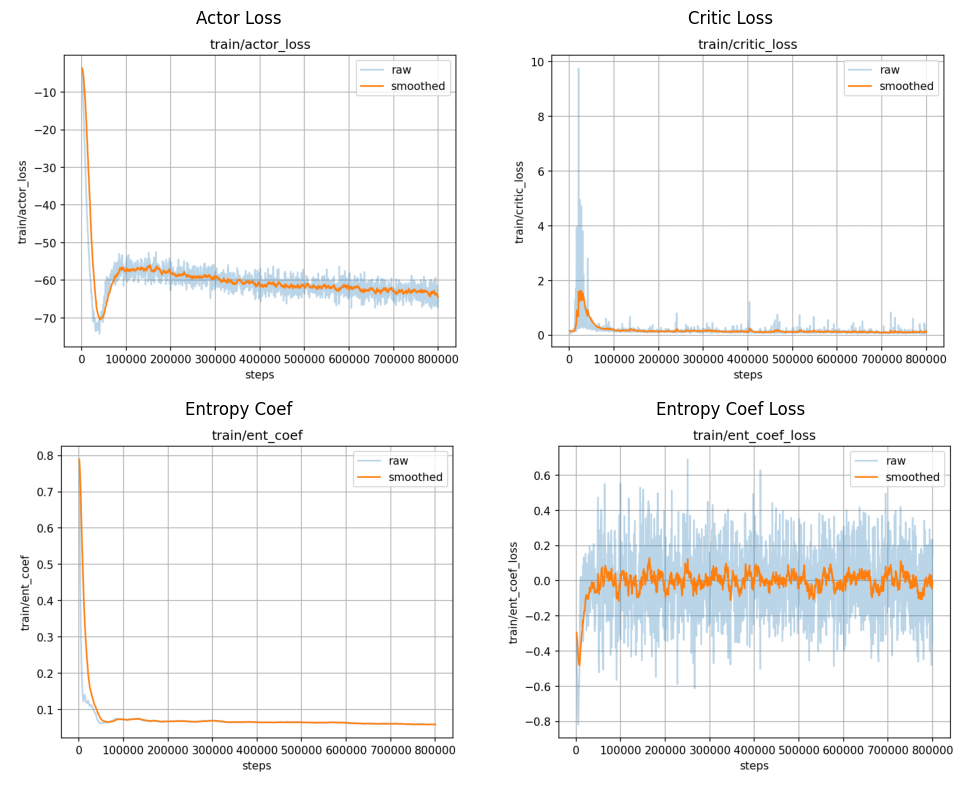

In [76]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

paths = [
    r"C:\\Users\\nol4n\\Documents\\pyIA\\modelos_logs\\plots\\sac_v1\\train_actor_loss.png",
    r"C:\\Users\\nol4n\\Documents\\pyIA\\modelos_logs\\plots\\sac_v1\\train_critic_loss.png",
    r"C:\\Users\\nol4n\\Documents\\pyIA\\modelos_logs\\plots\\sac_v1\\train_ent_coef.png",
    r"C:\\Users\\nol4n\\Documents\\pyIA\\modelos_logs\\plots\\sac_v1\\train_ent_coef_loss.png",
]

titles = [
    "Actor Loss",
    "Critic Loss",
    "Entropy Coef",
    "Entropy Coef Loss"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    img = mpimg.imread(paths[i])
    ax.imshow(img)
    ax.set_title(titles[i])
    ax.axis("off")

plt.tight_layout()
plt.savefig(r"Panel.png", dpi=200)
plt.show()